OpenGAN: Open-Set Recognition via Open Data Generation
================
**Supplemental Material for ICCV2021 Submission**


In this notebook, we demonstrate how we train the GAN-fea model on the cifar10 train-set, providing the closed-set images.

import packages
------------------

Some packages are installed automatically through Anaconda. PyTorch should be also installed.

In [13]:
from __future__ import print_function, division
import os, random, time, copy
#from skimage import io, transform


import sys

import matplotlib.pyplot as plt

#from skimage import data, img_as_float
#from skimage.measure import compare_ssim as ssim
#from skimage.measure import compare_psnr as psnr

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler 
import torch.nn.functional as F
from torch.autograd import Variable

from torchvision import datasets, models, transforms
import torchvision.utils as vutils

# from utils.eval_funcs import *
# from utils.dataset_cifar10 import *

import warnings # ignore warnings
warnings.filterwarnings("ignore")
print(sys.version)
print(torch.__version__)

sys.path.append(os.path.abspath(".."))
from Utils import *
from Utils_OpenGan import *
manualSeed = 42
fix_random_seed(manualSeed)

3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
2.9.1+cu128


Setup config parameters
 -----------------
 
 There are several things to setup, like which GPU to use, where to read images and save files, etc. Please read and understand this. By default, you should be able to run this script smoothly by changing nothing.

In [14]:

################## set attributes for this project/experiment ##################
# config result folder
exp_dir = './Experimentos/Cifar10/' # experiment directory, used for reading the init model

modelFlag = "ResNet18"

project_name = 'OpenGan_cifar10' + modelFlag   # we save all the checkpoints in this directory

# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available(): 
    device='cuda:0'


total_epoch_num = 200 # total number of epoch in training
batch_size = 128    

newsize = (64, 64)


path_to_feats = os.path.join(NOMES.FEATS_DIR.value, "CIFAR",NOMES.RESNET18.value) # the path to cached off-the-shelf features

# For GAN-fea, we set the hyper-parameters as below.

# Number of channels in the training images. For color images this is 3
nc = 512

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Beta1 hyperparam for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1



# cifar10 has 200 classes.
nClassTotal = 200
nClassCloseset = nClassTotal

#project_name += '_K{}run{}'.format(nClassCloseset, runIdx)
if not os.path.exists(exp_dir): os.makedirs(exp_dir)

lr = 0.0001 # learning rate

num_epochs = total_epoch_num
torch.cuda.device_count()
torch.cuda.empty_cache()

save_dir = os.path.join(exp_dir, project_name)
print(save_dir)    
if not os.path.exists(save_dir): os.makedirs(save_dir)

log_filename = os.path.join(save_dir, 'train.log')

./Experimentos/Cifar10/OpenGan_cifar10ResNet18


Define model architecture
---------

Here is the definition of the model architectures for generator and discriminator. Both are multi-layer perceptron (MLP) networks.

In [15]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)     
        

class Generator(nn.Module):
    def __init__(self, ngpu=1, nz=100, ngf=64, nc=512):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.nz = nz
        self.ngf = ngf
        self.nc = nc
        
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            # Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')
            nn.Conv2d( self.nz, self.ngf * 8, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ngf * 8),
            nn.ReLU(True),
            # state size. (self.ngf*8) x 4 x 4
            nn.Conv2d(self.ngf * 8, self.ngf * 4, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ngf * 4),
            nn.ReLU(True),
            # state size. (self.ngf*4) x 8 x 8
            nn.Conv2d( self.ngf * 4, self.ngf * 2, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ngf * 2),
            nn.ReLU(True),
            # state size. (self.ngf*2) x 16 x 16
            nn.Conv2d( self.ngf * 2, self.ngf*4, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ngf*4),
            nn.ReLU(True),
            # state size. (self.ngf) x 32 x 32
            nn.Conv2d( self.ngf*4, self.nc, 1, 1, 0, bias=True),
            #nn.Tanh()
            # state size. (self.nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

    
class Discriminator(nn.Module):
    def __init__(self, ngpu=1, nc=512, ndf=64):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.nc = nc
        self.ndf = ndf
        self.main = nn.Sequential(
            nn.Conv2d(self.nc, self.ndf*8, 1, 1, 0, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(self.ndf*8, self.ndf*4, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ndf*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(self.ndf*4, self.ndf*2, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ndf*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(self.ndf*2, self.ndf, 1, 1, 0, bias=False),
            nn.BatchNorm2d(self.ndf),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(self.ndf, 1, 1, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

## initialize the networks

In [16]:
netG = Generator(ngpu=ngpu, nz=nz, ngf=ngf, nc=nc).to(device)
netD = Discriminator(ngpu=ngpu, nc=nc, ndf=ndf).to(device)

# Handle multi-gpu if desired
if ('cuda' in device) and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

    # Apply the weights_init function to randomly initialize all weights
#  to mean=0, stdev=0.2.
netD.apply(weights_init)


if ('cuda' in device) and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))
netG.apply(weights_init)

print(device)

cuda:0


## Sanity Check

In [17]:
noise = torch.randn(batch_size, nz, 1, 1, device=device)
# Generate fake image batch with G
fake = netG(noise)
predLabel = netD(fake)

print(noise.shape, fake.shape, predLabel.shape)

torch.Size([128, 100, 1, 1]) torch.Size([128, 512, 1, 1]) torch.Size([128, 1, 1, 1])


## setup dataset of cifar10

In [18]:
cifar10_train_data = torch.load(os.path.join(path_to_feats,"CIFAR_train_features.pt"),map_location='cpu')



## a helper function to read cached off-the-shelf features per closed images

In [19]:
class FeatDataset(Dataset):
    def __init__(self, data):
        self.features = data["features"]
        self.labels = data["labels"]
        self.current_set_len = self.features.shape[0]        
        
    def __len__(self):        
        return self.current_set_len
    
    def __getitem__(self, idx):        
        return self.features[idx]
    
    def get_label(self,idx):
        return self.labels[idx]

In [20]:
trainset_closeset = FeatDataset(data=cifar10_train_data)
print(trainset_closeset.__getitem__(2))
dataloader = DataLoader(trainset_closeset, batch_size=batch_size, shuffle=True, num_workers=1)

tensor([0.2707, 0.1141, 0.3184, 0.6825, 2.7563, 0.5943, 1.1982, 0.3566, 0.4641,
        1.3404, 0.6631, 0.6043, 0.7638, 0.0067, 0.1397, 2.2627, 3.1398, 0.9024,
        1.2449, 1.7463, 2.8492, 0.2910, 0.6029, 0.2413, 1.3394, 0.0783, 0.5274,
        0.8086, 0.8283, 1.4709, 1.7190, 2.2809, 2.8891, 0.3351, 1.4177, 2.5115,
        3.9372, 0.0545, 0.0868, 0.4599, 0.3469, 1.8515, 1.8869, 0.0867, 0.3989,
        0.4652, 0.4705, 0.8779, 0.5704, 0.2837, 1.1997, 2.4358, 1.1529, 0.2929,
        2.4012, 3.5832, 0.2117, 0.3975, 1.7131, 0.4479, 2.6481, 1.5019, 0.3122,
        0.6228, 1.6818, 2.2733, 2.4843, 1.8296, 1.8448, 0.4163, 1.1123, 0.4221,
        1.5787, 0.1884, 0.8075, 0.1529, 0.0918, 1.5447, 0.4219, 2.1676, 2.0827,
        0.7469, 0.5242, 0.4138, 0.1348, 1.0495, 1.1521, 1.4735, 0.0711, 0.4785,
        1.9476, 0.4864, 1.7236, 0.2739, 0.0000, 2.5234, 1.7037, 0.4763, 2.1936,
        0.6936, 0.5507, 0.2673, 1.4732, 0.4450, 2.5855, 0.2014, 0.6766, 0.2361,
        0.8373, 0.1625, 0.3903, 0.3016, 

In [21]:
data_sampler = iter(dataloader)
feaList = next(data_sampler)
print(feaList.shape)

torch.Size([128, 512])


setup training
-----------

In [22]:
# Initialize BCELoss function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1
fake_label = 0

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr/1.5, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [23]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data.to(device)
        real_cpu = real_cpu.view(real_cpu.size(0), nc, 1, 1).to(device,dtype=torch.float32)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, device=device,dtype=torch.float32)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        #print(output.shape)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()
        

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 200 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1
        
    
    #cur_model_wts = copy.deepcopy(netG.state_dict())
    #path_to_save_paramOnly = os.path.join(save_dir, 'epoch-{}.GNet'.format(epoch+1))
    #torch.save(cur_model_wts, path_to_save_paramOnly)
    
    cur_model_wts = copy.deepcopy(netD.state_dict())
    path_to_save_paramOnly = os.path.join(save_dir, 'epoch-{}.DNet'.format(epoch+1))
    torch.save(cur_model_wts, path_to_save_paramOnly)

Starting Training Loop...
[0/200][0/352]	Loss_D: 1.3927	Loss_G: 0.7413	D(x): 0.4788	D(G(z)): 0.4794 / 0.4775
[0/200][200/352]	Loss_D: 1.2899	Loss_G: 0.7599	D(x): 0.5213	D(G(z)): 0.4707 / 0.4682
[1/200][0/352]	Loss_D: 1.2238	Loss_G: 0.7898	D(x): 0.5447	D(G(z)): 0.4582 / 0.4544
[1/200][200/352]	Loss_D: 1.1279	Loss_G: 0.8409	D(x): 0.5765	D(G(z)): 0.4367 / 0.4325
[2/200][0/352]	Loss_D: 1.1216	Loss_G: 0.8696	D(x): 0.5715	D(G(z)): 0.4270 / 0.4207
[2/200][200/352]	Loss_D: 1.0199	Loss_G: 0.9222	D(x): 0.6101	D(G(z)): 0.4061 / 0.3995
[3/200][0/352]	Loss_D: 0.9593	Loss_G: 0.9750	D(x): 0.6272	D(G(z)): 0.3861 / 0.3796
[3/200][200/352]	Loss_D: 0.8916	Loss_G: 1.0431	D(x): 0.6460	D(G(z)): 0.3616 / 0.3549
[4/200][0/352]	Loss_D: 0.8689	Loss_G: 1.0874	D(x): 0.6471	D(G(z)): 0.3462 / 0.3396
[4/200][200/352]	Loss_D: 0.7437	Loss_G: 1.1818	D(x): 0.7017	D(G(z)): 0.3187 / 0.3109
[5/200][0/352]	Loss_D: 0.6833	Loss_G: 1.3011	D(x): 0.7138	D(G(z)): 0.2880 / 0.2785
[5/200][200/352]	Loss_D: 0.6042	Loss_G: 1.3080	D(x)

## drawing the error curves

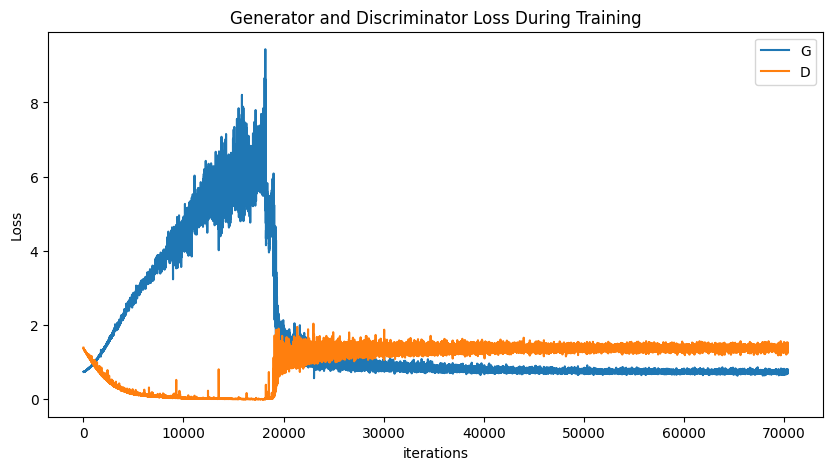

In [24]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig('learningCurves_{}.png'.format(modelFlag), bbox_inches='tight',transparent=True)
# plt.show()